
# Bitácora — Franck–Hertz (Hg)
**Universidad de los Andes — Laboratorio Intermedio**  
**Fecha:** 2025-09-16 19:36  
**Estudiantes:** Ángela Bustos , Mariana Montoya. 
**Correos:** av.bustos@uniandes.edu.co , 

**Sitio de guardado:** https://github.com/ValentinaBustos2025/Lab-Intermedio.git (en la nube).

**Carpeta :** Fran Herz

**Archivo:** Bitácora.ipynb

<p align="center">
  <img src="guardado.jpg" alt="Mi imagen" width="600">
</p>

---
## Objetivos
- Medir la cuantización de la energía de estados electrónicos en átomos de Mercurio (Hg).
- Entender cómo la temperatura afecta la densidad del gas y el camino libre medio.
- Calcular la energía entre el estado base y el primer estado excitado del Hg.

---
## Marco Teórico

En 1914, James Franck y Gustav Hertz demostraron experimentalmente la **cuantización de la energía** en átomos de mercurio (Hg), validando la idea central de la teoría de **Bohr** (1913): los electrones en los átomos ocupan **niveles discretos** de energía y las transiciones entre ellos implican ganancias o pérdidas de paquetes de energía bien definidos.

### 1) Fundamentos de Bohr (contexto)
- Los electrones se mueven en **órbitas estacionarias** con energías cuantizadas.  
- La emisión/absorción de radiación ocurre cuando el electrón **salta** entre niveles con diferencia de energía **ΔE = hν**.  
- Aunque Bohr formuló su modelo para el hidrógeno, el hallazgo de Franck–Hertz mostró que la **cuantización** también se manifiesta en átomos multielectrónicos (como Hg) mediante impactos electrónicos.

### 2) Colisiones electrón–átomo en Hg
- **Elásticas:** el electrón cambia de dirección, pero la **energía cinética** total se conserva (la pérdida es despreciable debido a que $m_e \ll M_{\mathrm{Hg}}$).  

- **Inelásticas:** si la energía del electrón supera el umbral de excitación $E_a$, transfiere aproximadamente \(E_a\) al átomo (p. ej., 4.67 eV para el primer estado excitado relevante de Hg), dejando menos energía cinética remanente.

Como consecuencia, al **aumentar** el voltaje acelerador $U_1$, la corriente medida $I_A$ exhibe **mínimos periódicos**: en cada umbral, muchos electrones sufren colisiones inelásticas y **no** alcanzan el ánodo (o no superan $U_2$), produciendo una caída en $I_A$.

### 3) Rol de la temperatura y el camino libre medio
La **densidad** de átomos de Hg en el tubo depende de la **presión de vapor** y la **temperatura**. Modelando el Hg como gas ideal, $n = P/(k_B T)$. El **camino libre medio**,
\[
\bar{\ell} = \frac{1}{\sqrt{2}\,n\,\sigma},
\]
representa la distancia promedio entre colisiones electrón–átomo (con $\sigma \approx \pi r^2$ una sección eficaz efectiva).  
- Si $\bar{\ell} \ll L$ (siendo $L$ la distancia cátodo–ánodo), **se incrementa** la probabilidad de múltiples colisiones dentro del tubo y aparecen **varios** mínimos/ máximos en $I_A(U_1)$.  
- Si $\bar{\ell}$ es **comparable** a $L$, disminuye el número de colisiones y se **suprime** la estructura de picos.

### 4) Voltaje de retardo $U_2$ y emisión termoiónica $U_H$
- **\(U_2\)** (retardo) establece un umbral de energía: solo los electrones con energía cinética suficiente lo superan y contribuyen a \(I_A\). Al **aumentar** \(U_2\), se filtran más electrones de baja energía, lo que **desplaza** o **acentúa** los mínimos.  
- **\(U_H\)** (calentamiento del cátodo) controla la **emisión termoiónica** y la distribución de energías iniciales de los electrones (tipo Maxwell–Boltzmann). Cambios en \(U_H\) afectan la **amplitud** de \(I_A\), el **ancho** de valles/picos y la reproducibilidad.

### 5) Distancias entre mínimos y estimación de $E_a$ y $\bar{\ell}$
Denotando por $U_1^{(n)}$ la posición del **n-ésimo mínimo** de $I_A(U_1)$, la **separación** entre mínimos consecutivos $\Delta E(n) = U_1^{(n)} - U_1^{(n-1)}$ (en voltios ~ eV) crece débilmente con $n debido a que, con mayores $U_1$, el electrón gana energía adicional en cada tramo libre $\bar{\ell}$. Un modelo efectivo predice:
\[
\Delta E(n) \approx \left(1 + \frac{\bar{\ell}}{L}(2n-1)\right) E_a.
\]
- Ajustando $\Delta E(n)$ vs. $n$ se obtiene la **pendiente** que permite estimar $\bar{\ell}_{\mathrm{exp}}$.  
- Extrapolando a $n=1/2$, se estima $E_a \approx \Delta E(0.5)$, que se compara con el valor tabulado de Hg (~4.67 eV).

**Conclusión teórica:** la aparición de mínimos periódicos en $I_A(U_1)$ y su **separación característica** constituyen una verificación directa de la **cuantización** de los niveles atómicos. La sensibilidad de la curva a $T$, $U_2$ y $U_H$ habilita, además, la **caracterización** del medio (densidad/camino libre) y del proceso de emisión.


---

## Montaje Experimental
- Tubo de Franck-Hertz en estufa.  
- Módulo de control y medición (conexiones: UH, U1, U2).  
- Osciloscopio para modo XY.  
- Software *Phywe Measure 4* para adquisición de datos.  

Precauciones:  
- T < 190 °C.  
- U1 < 60 V, UH < 7 V, U2 < 3 V.  


<p align="center">
  <img src="montaje.jpg" alt="Mi imagen" width="600">
</p>

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                
                continue

    return np.array(columnas)


---

## Actividad 1

1. Con la ayuda del osciloscopio puede medir aproximadamente la distancia entre los mínimos. ¿Concuerda esta distancia con los valores esperados.

2. Mueva los cursores del osciloscopio tal que uno de los picos quede centrado en el origen y apague la estufa. Describa el comportamiento de los picos a medida que disminuye la temperatura y justifique sus observaciones. No deje que baje a más de 160◦C y cuando sea necesario disminuya el voltaje máximo U1.

3. Describa que sucede con la curva observada si cambia el voltaje U2 a 1,5V o a 1V a una temperatura constante.

4. Para obtener los máximos y mínimos puede ir al menú Análisis y luego Análsis de curva. Controlando la sensibilidad del análisis para detectar m´aximos y m´ınimos y mostr´ando los en la gráfica puede obtener figuras como la Fig.8. Las figuras las puede guardar para su reporte y la serie de datos, así como la información de máximos y mínimos la puede guardar/exportar para su posterior an´alisis. Si quiere guardar la serie completa de datos vaya a File y de clic en la opción Imprimir Datos. El software lo puede descargar libremente
para abrir las series de datos y poder realizar las gráficas pedidas para el informe.

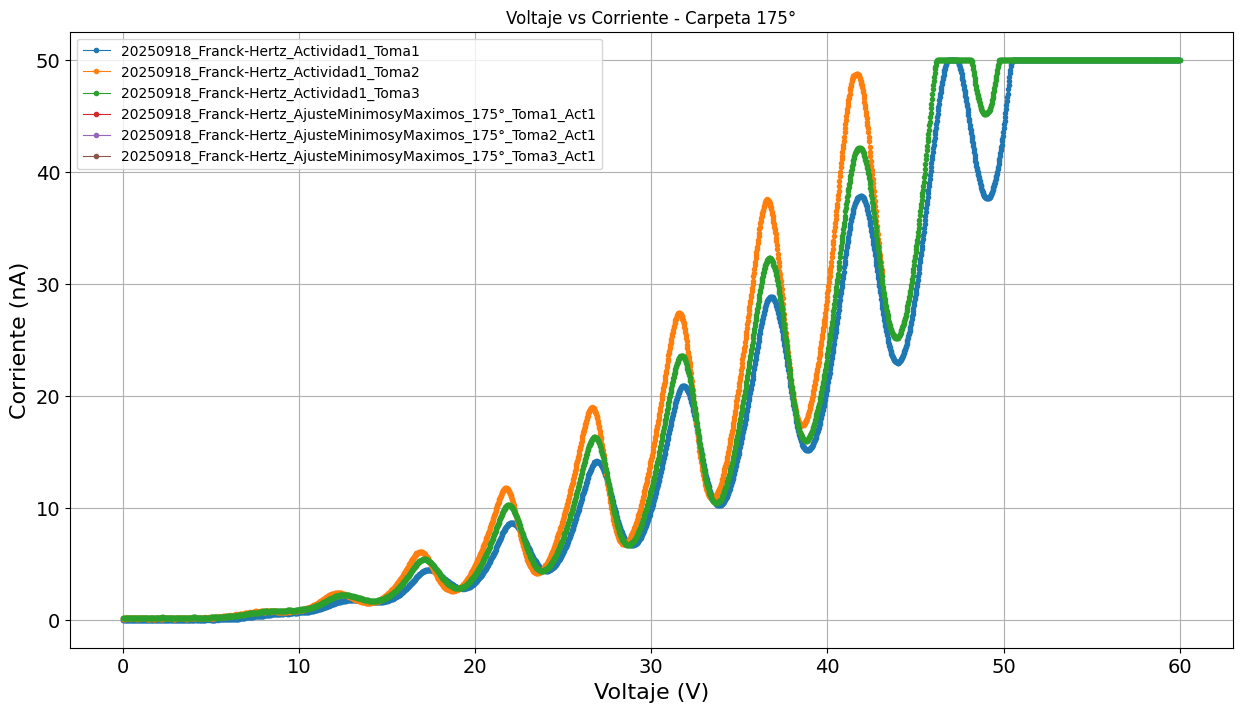

In [9]:
from pathlib import Path

carpeta = Path("Data/Act1/175°")  # ruta 

plt.figure(figsize=(15,8))

for archivo in carpeta.glob("*.txt"):
    
    
    voltajes = []
    corrientes = []
    
    with open(archivo, "r", encoding="utf-8") as f:
        # Saltar encabezados (2 primeras líneas)
        next(f)
        next(f)
        
        for linea in f:
            linea = linea.strip()
            if not linea:
                continue
            partes = linea.split("\t")
            
            try:
                v = float(partes[0].replace(",", "."))
                i = float(partes[1].replace(",", "."))
            except ValueError:
                # Si no se puede convertir (ej: "mínimo"), lo ignora
                continue
            
            voltajes.append(v)
            corrientes.append(i)
    
    # Graficar cada archivo con su nombre
    plt.plot(voltajes, corrientes, marker="o", markersize=3, linewidth=0.8, label=archivo.stem)


plt.xlabel("Voltaje (V)", fontsize = 16)
plt.ylabel("Corriente (nA)", fontsize = 16)
plt.title("Voltaje vs Corriente - Carpeta 175°")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.show()





---

## Actividad 2

1. Tome varias series de datos con la misma temperatura, procure que las variaciones en esta sean m´ınimas. ¿C´omo se comparan las diferentes gr´aficas? ¿C´omo afectan estas peque˜nas fluctuaciones en la temperatura a sus resultados? ¿Se justifica un an´alisis estad´ıstico?

2. Para valores de UH y U2 constantes registre la corriente IA y el voltaje U1 para diferentes temperaturas en el intervalo 165◦C-185◦C. 

3. Con los datos para cada temperatura calcule la distancia entre m´ınimos y comp´arela con el valor esperado de 4,67eV . ¿ C´omo puede explicar las discrepancias. 

4. Concentr´andose en valores menores registre d´onde ocurre el primer m´ınimo. ¿Por qu´e no sucede en 4,67eV ? ¿Qu´e podr´ıa calcular sabiendo la posici´on del primer m´ınimo? (Ayuda: tenga en cuenta el voltaje de retardo U2.)

5.Para un valor de temperatura fijo cambie el valor de U2 (entre 1V y 2V) y registre los valores medidos de IA en funci´on de U1. Haga una sola gr´afica con sus resultados.

6. Para un valor de U2 y temperatura fijos. Cambie el valor de UH en el rango (6,3 ± 0,5)V . Explique c´omo cambia la curva IA vs U1 y sustente su respuesta en t´erminos de la emisi´on termoi´onica, la temperatura del c´atodo y la distribuci´on de Maxwell- Boltzmann de los electrones que de all´ı son emitidos. Use esta respuesta para sus-
tentar el ancho en los valles y picos del patr´on observado.

7. Con las mediciones que ya ha realizado haga una gr´afica de distancia entre m´ınimos
en funci´on del orden del m´ınimo. ¿Observa este comportamiento creciente lineal? (Las diferencias son relativamente peque˜nas as´ı que procure hacer las mediciones con la mayor precisi´on posible). Para cada temperatura obtenga una regresi´on lineal (entre distancia entre m´ınimos y orden del m´ınimo) y con el valor de la pendiente
calcule el camino libre medio experimental con la ecuaci´on 
¯`exp = L
2Ea
d∆E(n)
dn , (8)
comparando sus resultados con los que obtuvo en el punto 2 del Ejercicio 3).
Adicionalmente, con las regresiones que realiz´o, calcule el valor de Ea mediante la
evaluaci´on de ∆E(0,5), compare su valor con el valor reportado de 4.67eV. Use un
valor de L = 12cm.

---

## Para Considerar

1. ¿En qu´e magnitud cree que afectan las siguientes variables en el experimento? 
- Campo magn´etico terrestre o campos electromagn´eticos externos. 
-La condici´on de vac´ıo en el tubo de Frank-Hertz.
-No uniformidad del campo el´ectrico que acelera los electrones.
-No uniformidad de la temperatura en la estufa
2. ¿C´omo podr´ıa (si es posible) minimizar los efectos de las variables mencionadas en
el punto anterior?